# Bring Your Own Data: classification & regression with TorchLogix

This notebook shows how to apply TorchLogix to **your own tabular data** for both a
**classification** and a **regression** task. 

It differs from an ordinary PyTorch model in the following ways:

1. **Binarization** — logic gates consume Boolean bits, so continuous features are
   thermometer-encoded into `{0, 1}` values.
2. **Architecture** — logic nets want to be wide; the output head differs by task
   (a `GroupSum` for classification, a learnable *popcount* head for regression).
3. **Relaxed vs. discrete** — you train a continuous relaxation but deploy a hard
   Boolean circuit; always judge the *discrete* model.

For the full training → compile → export pipeline see
[`mnist_example.ipynb`](mnist_example.ipynb); the binarization layers are shown in §1.2 and documented in the
[Core Concepts guide](../docs/guides/concepts.md).

## A reusable training helper

We can use a standard torch based training loop. Each checkpoint
 reports a metric in **both** modes: `model.eval()` = hard/discrete gates (what
you deploy) and `model.train()` = the continuous relaxation.

In [1]:
import numpy as np, torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(0); np.random.seed(0)

def train(model, loader, *, epochs, lr, loss_fn, eval_fn, label='metric'):
    """Generic logic-net loop. loss_fn(out, y)->loss; eval_fn()->float metric on
    held-out data in whichever mode (train/eval) the model is currently in."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    every = max(1, epochs // 8)
    hist = {'epoch': [], 'discrete': [], 'relaxed': []}
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in loader:
            opt.zero_grad(); loss_fn(model(x), y).backward(); opt.step()
        if epoch == 1 or epoch % every == 0 or epoch == epochs:
            model.eval();  d = eval_fn()
            model.train(); r = eval_fn()
            hist['epoch'].append(epoch); hist['discrete'].append(d); hist['relaxed'].append(r)
            print(f'epoch {epoch:4d} | {label}  discrete {d:.3f}  relaxed {r:.3f}')
    return hist

# Part 1 — Classification (Breast Cancer)

Binary classification of 569 tumours from 30 continuous features (bundled in sklearn).

## 1.1 Load and split

We use a feature matrix `X (n_samples, n_features)` and integer labels `y`. **Split
before computing any statistics** — thresholds are fit on the training split only, or
you leak test information. Note the very different feature scales below (why
*per-feature* thresholds matter).

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
bc = load_breast_cancer()
Xc, yc = bc.data.astype('float32'), bc.target.astype('int64')
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.25, random_state=0, stratify=yc)
Xc_tr, Xc_te = torch.from_numpy(Xc_tr), torch.from_numpy(Xc_te)
yc_tr, yc_te = torch.from_numpy(yc_tr), torch.from_numpy(yc_te)
print(f'train {tuple(Xc_tr.shape)}, test {tuple(Xc_te.shape)}, classes {np.unique(yc)}')
for name, lo, hi in zip(bc.feature_names[:4], Xc.min(0)[:4], Xc.max(0)[:4]):
    print(f'  {name:20s} {lo:8.2f} .. {hi:8.2f}')

train (426, 30), test (143, 30), classes [0 1]
  mean radius              6.98 ..    28.11
  mean texture             9.71 ..    39.28
  mean perimeter          43.79 ..   188.50
  mean area              143.50 ..  2501.00


## 1.2 Binarize — the key data decision

Each continuous feature becomes `num_bits` bits by comparison with `num_bits`
increasing thresholds (`bit_i = 1` iff `x > t_i`); sorted thresholds give an ordinal,
monotone **thermometer code**. Three choices:

| Knob | Meaning | Guidance |
|------|---------|----------|
| `num_bits` | bits per feature | 3–7 for classification; more = finer but wider input (`n_features*num_bits`) |
| `method` | `'distributive'` = quantile thresholds; `'uniform'` = evenly spaced min→max | prefer `'distributive'` for skewed features |
| `one_per` | `'feature'` vs `'global'` (`'channel'` for images) | use `'feature'` when columns have different scales |

Fit on **train**, reuse everywhere.

In [3]:
from torchlogix.layers import Binarization, FixedBinarization, LogicDense, GroupSum
NUM_BITS = 5
thr_c = Binarization.get_initial_thresholds(Xc_tr, num_bits=NUM_BITS, one_per='feature', method='distributive')
binarize_c = FixedBinarization(thr_c)   # (B, F) -> (B, F*num_bits) of 0/1
print('thresholds', tuple(thr_c.shape), '-> input width', Xc_tr.shape[1]*NUM_BITS)

thresholds (30, 5) -> input width 150


### Choosing the binarization *layer*

`FixedBinarization` is the workhorse, but TorchLogix ships four binarization layers
(all in `torchlogix.layers`) that share the thresholds above and differ only in how
they behave during training:

| Layer | Thresholds | Training forward | Use when |
|-------|-----------|------------------|----------|
| `FixedBinarization` | fixed | hard `x > t` | default: fit thresholds once and freeze them |
| `SoftBinarization` | fixed | `sigmoid((x−t)/τ)` (differentiable) | you want gradients to flow to pre-threshold values; anneal `τ`→0 |
| `LearnableBinarization` | **learned** | sampled (`soft`/`hard`/`gumbel`) | let the thresholds adapt during training |
| `DummyBinarization` | — | pass-through | inputs are already binary |

All produce the same `(B, F*num_bits)` hard output in `eval()`; they differ in the
training forward. Below we construct each on two samples — note `DummyBinarization`
is a pass-through (keeps the raw `F` features) and `LearnableBinarization` carries
trainable parameters:

In [4]:
from torchlogix.layers import SoftBinarization, LearnableBinarization, DummyBinarization

x_demo = Xc_tr[:2]
for name, layer in [('Fixed',     FixedBinarization(thr_c)),
                    ('Soft',      SoftBinarization(thr_c)),
                    ('Learnable', LearnableBinarization(thr_c)),
                    ('Dummy',     DummyBinarization())]:
    layer.eval()
    out = layer(x_demo)
    n_learn = sum(p.numel() for p in layer.parameters() if p.requires_grad)
    print(f'{name:10s} out shape {tuple(out.shape)}   trainable params: {n_learn}')

# We use FixedBinarization for the rest of the notebook.

Fixed      out shape (2, 150)   trainable params: 0
Soft       out shape (2, 150)   trainable params: 0
Learnable  out shape (2, 150)   trainable params: 150
Dummy      out shape (2, 30)   trainable params: 0


## 1.3 Build the model — architecture choices

| Choice | What it does | Rule of thumb |
|--------|--------------|---------------|
| **width** | number of logic neurons | go wide — each neuron is only a 2-input gate |
| **depth** | # `LogicDense` layers | 2–10 typical |
| `GroupSum(k, tau)` | head: sums neurons into `k` class scores / temperature `tau` | `k`=#classes; last width divisible by `k`; small `tau` |
| `weight_init` (in `parametrization_kwargs`) | `'residual'` (default) vs `'random'` | default is fine; if the *discrete* curve lags, train longer / lower `tau` / use `'random'` |

In [5]:
WIDTH = 1024
model_c = nn.Sequential(
    binarize_c,
    LogicDense(Xc_tr.shape[1]*NUM_BITS, WIDTH),
    LogicDense(WIDTH, WIDTH),
    GroupSum(k=2, tau=10.0),
)
print(model_c)

Sequential(
  (0): FixedBinarization()
  (1): LogicDense(
    150, 1024
    weight: Parameter containing: [torch.float32 of size (1024, 16)]
    parametrization: RawLUTParametrization
    connections: FixedDenseConnections, FixedDenseConnections()
    (parametrization): RawLUTParametrization()
    (connections): FixedDenseConnections()
  )
  (2): LogicDense(
    1024, 1024
    weight: Parameter containing: [torch.float32 of size (1024, 16)]
    parametrization: RawLUTParametrization
    connections: FixedDenseConnections, FixedDenseConnections()
    (parametrization): RawLUTParametrization()
    (connections): FixedDenseConnections()
  )
  (3): GroupSum(k=2, tau=10.0)
)


## 1.4 Train & evaluate

Use a large learning rate (Adam ~0.01–0.05). The **discrete** accuracy is what you
deploy and it should track the relaxed one.

In [6]:
train_c = DataLoader(TensorDataset(Xc_tr, yc_tr), batch_size=64, shuffle=True)
test_c  = DataLoader(TensorDataset(Xc_te, yc_te), batch_size=256)
@torch.no_grad()
def clf_acc():
    correct = total = 0
    for x, y in test_c:
        correct += (model_c(x).argmax(-1) == y).sum().item(); total += y.numel()
    return correct / total
hist_c = train(model_c, train_c, epochs=80, lr=0.02,
               loss_fn=nn.CrossEntropyLoss(), eval_fn=clf_acc, label='acc')

epoch    1 | acc  discrete 0.517  relaxed 0.685


epoch   10 | acc  discrete 0.517  relaxed 0.937


epoch   20 | acc  discrete 0.517  relaxed 0.951


epoch   30 | acc  discrete 0.559  relaxed 0.951


epoch   40 | acc  discrete 0.846  relaxed 0.958


epoch   50 | acc  discrete 0.923  relaxed 0.958


epoch   60 | acc  discrete 0.958  relaxed 0.958


epoch   70 | acc  discrete 0.965  relaxed 0.958


epoch   80 | acc  discrete 0.965  relaxed 0.958


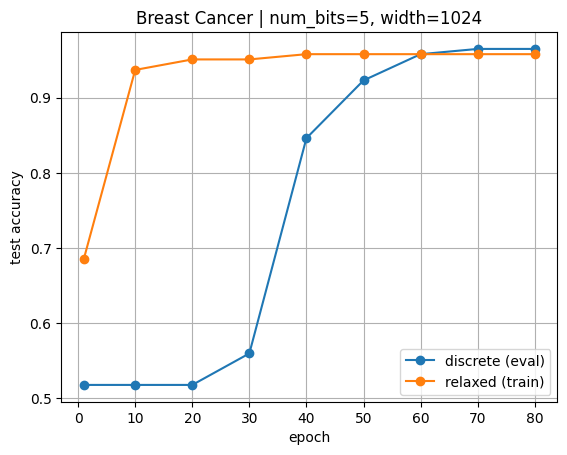

In [7]:
import matplotlib.pyplot as plt
plt.plot(hist_c['epoch'], hist_c['discrete'], '-o', label='discrete (eval)')
plt.plot(hist_c['epoch'], hist_c['relaxed'],  '-o', label='relaxed (train)')
plt.xlabel('epoch'); plt.ylabel('test accuracy'); plt.grid(True); plt.legend()
plt.title(f'Breast Cancer | num_bits={NUM_BITS}, width={WIDTH}'); plt.show()

# Part 2 — Regression (synthetic)

The data pipeline is identical; what changes is the **output head** and target
handling. We generate a synthetic regression dataset in-notebook (`make_regression`)
so it is self-contained and has a clear signal — unlike some small real regression
sets (e.g. sklearn `diabetes`), whose R² ceiling is ~0.45 even for the best models,
which would make *any* method look weak.

## 2.1 Generate, split, standardize the target

Regression targets are continuous, so we **standardize** them (zero mean / unit
variance) with *training* statistics, and undo it when reporting errors.

In [8]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
Xr, yr = make_regression(n_samples=4000, n_features=12, n_informative=8, noise=15.0, random_state=0)
Xr, yr = Xr.astype('float32'), yr.astype('float32')
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=0)
y_mean, y_std = yr_tr.mean(), yr_tr.std()
Xr_tr, Xr_te = torch.from_numpy(Xr_tr), torch.from_numpy(Xr_te)
yr_tr = torch.from_numpy((yr_tr - y_mean) / y_std)
yr_te = torch.from_numpy((yr_te - y_mean) / y_std)
ridge_r2 = Ridge().fit(Xr_tr.numpy(), yr_tr.numpy()).score(Xr_te.numpy(), yr_te.numpy())
print(f'train {tuple(Xr_tr.shape)}; linear (Ridge) baseline R2 = {ridge_r2:.3f}')

train (3000, 12); linear (Ridge) baseline R2 = 0.980


## 2.2 Binarize

Same thermometer encoding; regression benefits from a bit more resolution (`num_bits=8`).

In [9]:
NB_REG = 8
thr_r = Binarization.get_initial_thresholds(Xr_tr, num_bits=NB_REG, one_per='feature', method='distributive')
binarize_r = FixedBinarization(thr_r)
print('regression input width', Xr_tr.shape[1]*NB_REG)

regression input width 96


## 2.3 The regression head — what to consider

A logic net has no natural scalar output, so the last layer's `W` Boolean gates are
pooled by a **popcount** (how many fire) and mapped to the target. The DLGN
literature (Kresse et al., *Differentiable Weightless Controllers*, arXiv:2512.01467;
and torchlogix's `feat-regression` `LearnableGroupLinear`) uses a **learned** affine
map on the *normalized* popcount — that is what we implement here:

1. **popcount** the last layer → one integer count in `[0, W]`;
2. **normalize** to `[-1, 1]` (`2·count/W − 1`) so the scale is width-independent;
3. a small **`nn.Linear`** learns the scale + shift to target space.

This learned mapping matters: a *hand-fixed* scale (e.g. `GroupSum(k=1, tau, beta)`)
also works but is weaker, and an `exp`-parameterized scale can be numerically
unstable. Everything else (binarization, width, depth, high LR) is unchanged.

In [10]:
class PopcountLinearHead(nn.Module):
    """popcount -> normalize to [-1, 1] -> learnable nn.Linear.
    Equivalent to torchlogix.layers LearnableGroupLinear (feat-regression branch)."""
    def __init__(self, k=1):
        super().__init__(); self.k = k; self.lin = nn.Linear(k, k)
    def forward(self, x):
        n = x.shape[-1] // self.k
        x = x.reshape(*x.shape[:-1], self.k, n).sum(-1)   # popcount per group
        x = 2 * x / n - 1.0                               # -> [-1, 1]
        return self.lin(x)                                # learned scale + shift

WIDTH_R = 1024
model_r = nn.Sequential(
    binarize_r,
    LogicDense(Xr_tr.shape[1]*NB_REG, WIDTH_R),
    LogicDense(WIDTH_R, WIDTH_R),
    PopcountLinearHead(k=1),
)
print(model_r)

Sequential(
  (0): FixedBinarization()
  (1): LogicDense(
    96, 1024
    weight: Parameter containing: [torch.float32 of size (1024, 16)]
    parametrization: RawLUTParametrization
    connections: FixedDenseConnections, FixedDenseConnections()
    (parametrization): RawLUTParametrization()
    (connections): FixedDenseConnections()
  )
  (2): LogicDense(
    1024, 1024
    weight: Parameter containing: [torch.float32 of size (1024, 16)]
    parametrization: RawLUTParametrization
    connections: FixedDenseConnections, FixedDenseConnections()
    (parametrization): RawLUTParametrization()
    (connections): FixedDenseConnections()
  )
  (3): PopcountLinearHead(
    (lin): Linear(in_features=1, out_features=1, bias=True)
  )
)


## 2.4 Train & evaluate

We track **R²** (variance explained; 0 = predicting the mean) in both modes, and
compare to the linear (Ridge) baseline printed above.

In [11]:
train_r = DataLoader(TensorDataset(Xr_tr, yr_tr), batch_size=128, shuffle=True)
test_r  = DataLoader(TensorDataset(Xr_te, yr_te), batch_size=512)
def mse_loss(out, y):
    return nn.functional.mse_loss(out.squeeze(-1), y)
@torch.no_grad()
def reg_r2():
    pred = torch.cat([model_r(x).squeeze(-1) for x, _ in test_r])
    ss_res = ((yr_te - pred)**2).sum(); ss_tot = ((yr_te - yr_te.mean())**2).sum()
    return (1 - ss_res/ss_tot).item()
hist_r = train(model_r, train_r, epochs=150, lr=0.02, loss_fn=mse_loss, eval_fn=reg_r2, label='R2')
print(f'\nlinear (Ridge) baseline R2 = {ridge_r2:.3f}')

epoch    1 | R2  discrete 0.268  relaxed 0.260


epoch   18 | R2  discrete 0.911  relaxed 0.926


epoch   36 | R2  discrete 0.916  relaxed 0.926


epoch   54 | R2  discrete 0.909  relaxed 0.924


epoch   72 | R2  discrete 0.909  relaxed 0.922


epoch   90 | R2  discrete 0.911  relaxed 0.918


epoch  108 | R2  discrete 0.908  relaxed 0.916


epoch  126 | R2  discrete 0.904  relaxed 0.914


epoch  144 | R2  discrete 0.900  relaxed 0.912


epoch  150 | R2  discrete 0.900  relaxed 0.911

linear (Ridge) baseline R2 = 0.980


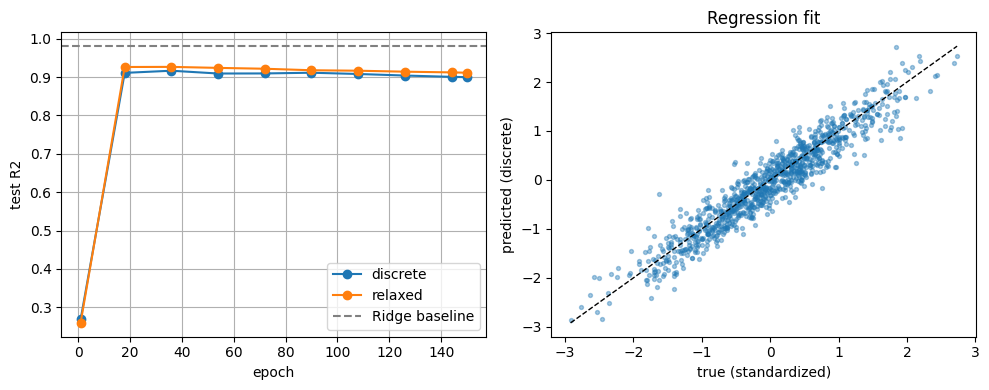

In [12]:
model_r.eval()
with torch.no_grad():
    pred = torch.cat([model_r(x).squeeze(-1) for x, _ in test_r]).numpy()
true = yr_te.numpy()
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(hist_r['epoch'], hist_r['discrete'], '-o', label='discrete')
ax[0].plot(hist_r['epoch'], hist_r['relaxed'],  '-o', label='relaxed')
ax[0].axhline(ridge_r2, ls='--', c='gray', label='Ridge baseline')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('test R2'); ax[0].grid(True); ax[0].legend()
ax[1].scatter(true, pred, s=8, alpha=0.4); lim=[true.min(), true.max()]
ax[1].plot(lim, lim, 'k--', lw=1)
ax[1].set_xlabel('true (standardized)'); ax[1].set_ylabel('predicted (discrete)'); ax[1].set_title('Regression fit')
plt.tight_layout(); plt.show()

# What to take away

The recipe is the same for both tasks; only the head and target handling differ:

1. **Data:** get `X (n_samples, n_features)` and `y`; split first, fit all stats on train only.
2. **Binarize:** choose `num_bits`, `method='distributive'` for skewed data, `one_per='feature'`
   when scales differ. Input width becomes `n_features * num_bits`.
3. **Body:** go wide (hundreds–thousands), 2–4 `LogicDense` layers, high Adam LR.
4. **Head:**
   - **Classification** → `GroupSum(k=n_classes)` + `CrossEntropyLoss`; last width divisible by `k`.
   - **Regression** → pool the gates by **popcount**, normalize, and learn a linear map
     (`PopcountLinearHead` / `LearnableGroupLinear`) + `MSELoss`; **standardize the target**.
5. **Judge the discrete (eval) model**, keep the relaxed–discrete gap small, and compare to a
   simple baseline (e.g. Ridge) so you know whether the ceiling is the model or the data.

Next: sweep `num_bits`/`WIDTH`, try `method='uniform'` or `LearnableBinarization`, then compile a
trained model to a `Circuit` (see [`mnist_example.ipynb`](mnist_example.ipynb)).